# Molecular prediction over the whole axis (axis-100-3000)

Head metrics over all classes of this axis for training pixels, withheld test pixels, the rare-class test extension and the held-out images, to measure how the molecular prediction generalizes to new pixels and to new images.

## Introduction

The head predicts, per pixel, the probability that each train-observed molecule is annotated. Metrics are
computed per class and aggregated (macro and micro) in two ranking populations that treat unlabelled entries
differently.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* The head was trained with the variational PU loss: annotations are positive, missing annotations are unlabelled.
  `annotation_retrieval` therefore treats unlabelled entries as negatives and underestimates precision when
  annotations are incomplete; `operational_pn` removes entries with signal but no annotation.
* Threshold metrics use $\hat Y \ge 0.5$; VPU logits are treated as 0.5-anchored as in the earlier head analyses.
* Evaluations: `train`, `test`, `test_extended`, `test_combined` (test and extension together, the main per-class
  estimate for rare classes) and `heldout_image`.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Ranking populations: `annotation_retrieval` (every available entry; annotated = positive, everything else
  negative) and `operational_pn` (only evidence positives P and operational negatives N; unlabelled entries with
  signal at the ion's bins, U, are excluded). Evidence rule: peak above 1.19 % of the spectrum maximum within
  +/- 1 bin.
* AP: average precision per class; macro = mean over eligible classes (at least one positive and one negative in
  the evaluated population and training support); micro = one ranking over all eligible entries.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "prediction_global"
AXIS = "axis-100-3000"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

EVALUATIONS = ['train', 'test', 'test_combined', 'heldout_image']
EVALUATION_COLORS = {name: POPULATION_COLORS[name] for name in EVALUATIONS}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'micro_prevalence', 'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1',
                'hamming_loss']


def metric_table(frame, index, columns, column_order):
    """Mean +/- SD over repetitions of every metric of a long table (`metric`, `value`)."""
    long = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).copy()
    long['metric'] = pd.Categorical(long.metric, categories=[name for name in METRIC_ORDER if name in set(long.metric)], ordered=True)
    grouped = long.groupby([*index, 'metric', columns], observed=True).value
    cells = grouped.mean().map('{:.4f}'.format) + ' +/- ' + grouped.std().map('{:.4f}'.format)
    shown = cells.unstack(columns)
    return shown[[name for name in column_order if name in shown.columns]]


def metric_columns_table(frame, index):
    """Mean +/- SD over repetitions of every metric column of a wide table."""
    columns = [name for name in METRIC_ORDER if name in frame.columns]
    grouped = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).groupby(index)[columns]
    return grouped.mean().round(4).astype(str) + ' +/- ' + grouped.std().round(4).astype(str)

prediction = table('prediction')

Analysis: prediction_global | axis: axis-100-3000 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 100-3000 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`ranking_tables` (the same implementation as the earlier head analyses) is evaluated in the `inference` level on
every population, on test and extension together, and on every held-out image separately.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis prediction_global > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis          repetition model_id                                                                                                                                                      
axis-100-3000 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7052  0.5102       4.0381                   0.8771          1.0991        3.2           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6942  0.5129       4.0117                   0.8824          1.0917        2.0            True
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6851  0.4777       3.7285                   0.8647          1.0539        3.4           False
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7068  0.5122       4.0129                   0.8813          1.1247        2.8           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6951  0.5102       4.1471                   0.8816          1.1029        3.6           False

### Remarks

- Representative model: repetition 1 (mean rank 2.0 of 5; the others 2.8-3.6). Repetitions differ little (macro AP 0.685-0.707, $W_1$ 3.73-4.15), so the choice is weakly determined; images of another repetition would differ in detail, not in pattern (see the SD maps of `part_1_04`).

### Notes

## Aggregate prediction metrics per evaluation population

### Methodology

#### Theoretical

Macro AP weights every class equally, micro AP weights every entry equally; ROC AUC is threshold free;
micro precision, recall and F1 are evaluated at $\hat Y \ge 0.5$.

#### Implementation

`prediction` rows with scope `train_supported` (all classes observed in training).

#### Figure descriptions

One panel per metric; x = evaluation population, colour = ranking population, one point per repetition, bar =
mean. The table lists the complete metric set (mean +/- SD over repetitions) per ranking population and
evaluation population: macro and micro AP, ROC AUC, AP above prevalence, micro prevalence, macro and micro
precision, recall and F1 at 0.5 and the Hamming loss.

evaluation                                                train               test      test_extended      test_combined      heldout_image
population           metric                                                                                                                
annotation_retrieval average_precision        0.6760 +/- 0.0077  0.6973 +/- 0.0089  0.7151 +/- 0.0073  0.7084 +/- 0.0079  0.3761 +/- 0.0164
                     micro_average_precision  0.8773 +/- 0.0073  0.8774 +/- 0.0074  0.8695 +/- 0.0129  0.8696 +/- 0.0066  0.5809 +/- 0.0191
                     roc_auc                  0.9905 +/- 0.0004  0.9897 +/- 0.0004  0.9725 +/- 0.0009  0.9872 +/- 0.0005  0.7264 +/- 0.0125
                     micro_roc_auc            0.9951 +/- 0.0002  0.9951 +/- 0.0002  0.9862 +/- 0.0011  0.9936 +/- 0.0003  0.8129 +/- 0.0069
                     ap_above_prevalence      0.6242 +/- 0.0077  0.6451 +/- 0.0089  0.6292 +/- 0.0073  0.6509 +/- 0.0079  0.1538 +/- 0.0164
                     micro_prevalence         0.0518 +/- 0.0000  0.0522 +/- 0.0000  0.0859 +/- 0.0000  0.0574 +/- 0.0000  0.2222 +/- 0.0000
                     precision                0.5932 +/- 0.0129  0.5682 +/- 0.0130  0.5568 +/- 0.0095  0.5877 +/- 0.0096  0.3602 +/- 0.0436
                     recall                   0.5300 +/- 0.0178  0.5309 +/- 0.0157  0.4644 +/- 0.0142  0.5287 +/- 0.0167  0.1190 +/- 0.0120
                     f1                       0.5026 +/- 0.0148  0.5047 +/- 0.0151  0.4613 +/- 0.0133  0.5080 +/- 0.0153  0.1276 +/- 0.0160
                     micro_precision          0.8352 +/- 0.0055  0.8352 +/- 0.0054  0.8153 +/- 0.0186  0.8296 +/- 0.0084  0.6767 +/- 0.0274
                     micro_recall             0.8701 +/- 0.0091  0.8688 +/- 0.0092  0.7220 +/- 0.0126  0.8229 +/- 0.0098  0.2654 +/- 0.0273
                     micro_f1                 0.8523 +/- 0.0031  0.8516 +/- 0.0031  0.7657 +/- 0.0101  0.8262 +/- 0.0050  0.3807 +/- 0.0298
                     hamming_loss             0.0156 +/- 0.0003  0.0158 +/- 0.0003  0.0380 +/- 0.0018  0.0199 +/- 0.0006  0.1914 +/- 0.0054
operational_pn       average_precision        0.8230 +/- 0.0064  0.8319 +/- 0.0061  0.8641 +/- 0.0044  0.8488 +/- 0.0061  0.8037 +/- 0.0071
                     micro_average_precision  0.8973 +/- 0.0062  0.8977 +/- 0.0061  0.9614 +/- 0.0030  0.9048 +/- 0.0054  0.9281 +/- 0.0072
                     roc_auc                  0.9888 +/- 0.0004  0.9884 +/- 0.0004  0.9832 +/- 0.0006  0.9892 +/- 0.0004  0.8762 +/- 0.0115
                     micro_roc_auc            0.9940 +/- 0.0003  0.9939 +/- 0.0003  0.9928 +/- 0.0006  0.9936 +/- 0.0003  0.9294 +/- 0.0062
                     ap_above_prevalence      0.7230 +/- 0.0064  0.7316 +/- 0.0061  0.6697 +/- 0.0044  0.7416 +/- 0.0061  0.2624 +/- 0.0071
                     micro_prevalence         0.0838 +/- 0.0000  0.0842 +/- 0.0000  0.1487 +/- 0.0000  0.0939 +/- 0.0000  0.4744 +/- 0.0000
                     precision                0.6698 +/- 0.0136  0.6327 +/- 0.0149  0.6323 +/- 0.0082  0.6623 +/- 0.0094  0.5989 +/- 0.0460
                     recall                   0.5300 +/- 0.0178  0.5309 +/- 0.0157  0.4633 +/- 0.0143  0.5287 +/- 0.0167  0.1190 +/- 0.0120
                     f1                       0.5427 +/- 0.0182  0.5418 +/- 0.0168  0.5005 +/- 0.0157  0.5466 +/- 0.0179  0.1540 +/- 0.0157
                     micro_precision          0.8752 +/- 0.0041  0.8750 +/- 0.0042  0.9658 +/- 0.0025  0.8982 +/- 0.0035  0.9962 +/- 0.0028
                     micro_recall             0.8701 +/- 0.0091  0.8688 +/- 0.0092  0.7203 +/- 0.0127  0.8229 +/- 0.0098  0.2654 +/- 0.0273
                     micro_f1                 0.8726 +/- 0.0033  0.8719 +/- 0.0033  0.8251 +/- 0.0083  0.8589 +/- 0.0045  0.4185 +/- 0.0342
                     hamming_loss             0.0213 +/- 0.0004  0.0215 +/- 0.0004  0.0454 +/- 0.0018  0.0254 +/- 0.0007  0.3490 +/- 0.0132

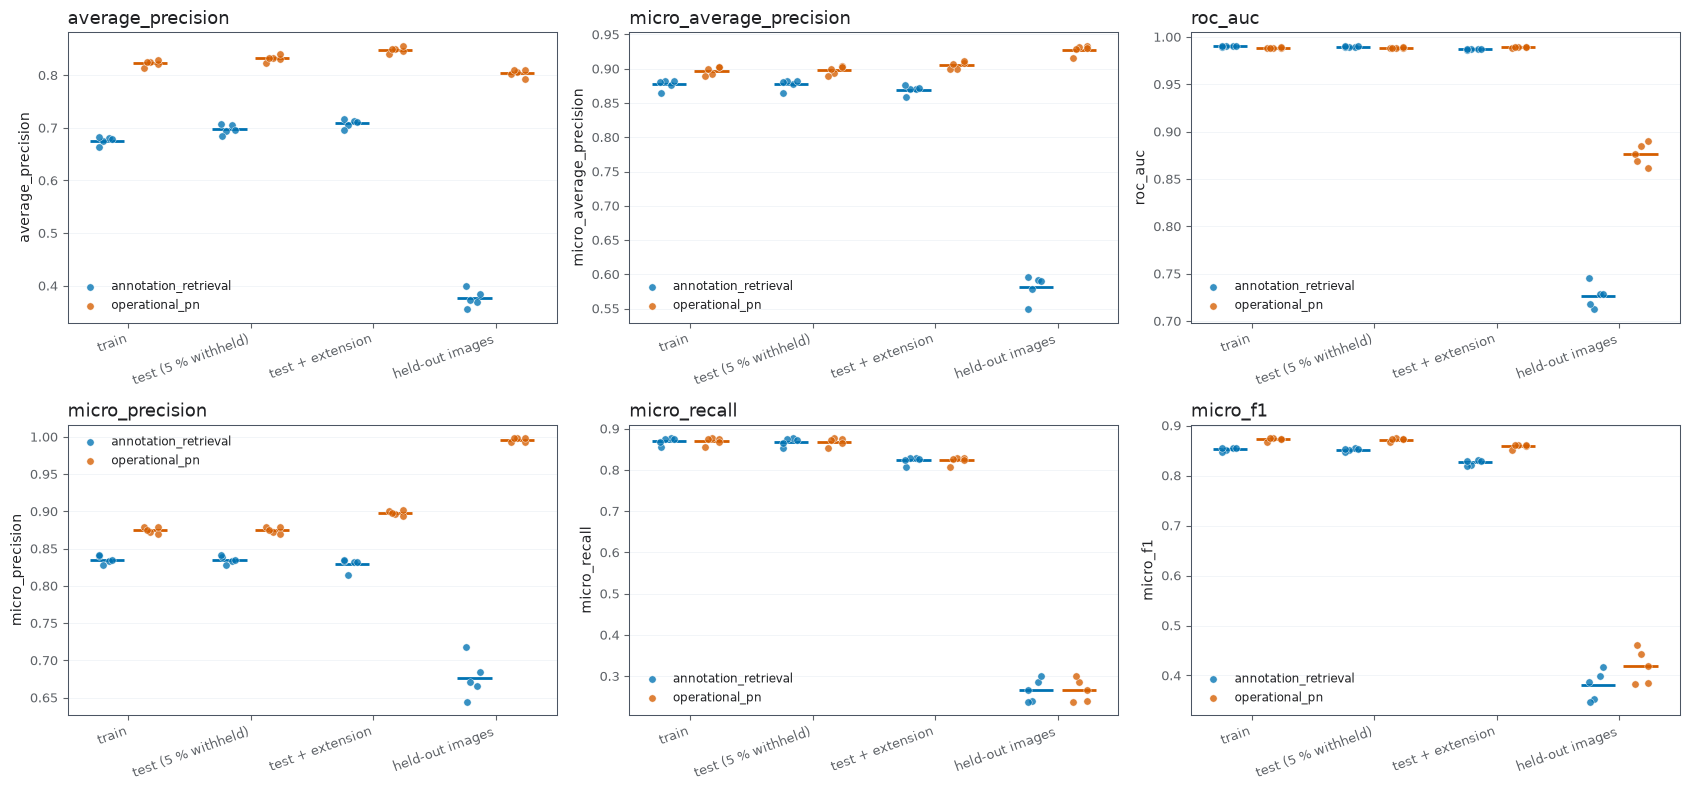

In [4]:
metrics = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_precision', 'micro_recall', 'micro_f1']
shown = prediction[(prediction.scope == 'train_supported') & prediction.metric.isin(metrics)]
figure, axes = plt.subplots(2, 3, figsize=(17, 8), dpi=theme.figure_dpi)
for ax, metric in zip(axes.flat, metrics):
    figures.repetition_points(shown[shown.metric == metric], value='value', group='evaluation', hue='population', order=EVALUATIONS, hue_order=['annotation_retrieval', 'operational_pn'], colors={'annotation_retrieval': theme.model_palette[0], 'operational_pn': theme.model_palette[1]}, ylabel=metric, title=metric, ax=ax, theme=theme)
figure.tight_layout()
full = prediction[prediction.scope == 'train_supported']
display(metric_table(full, ['population'], 'evaluation', ['train', 'test', 'test_extended', 'test_combined', 'heldout_image']))

### Remarks

- Test: macro AP 0.697, micro AP 0.877, micro ROC AUC 0.995, micro precision / recall 0.84 / 0.87, Hamming 0.016.
- Held-out pooled: macro AP 0.376, micro AP 0.581, micro precision / recall 0.68 / 0.27, Hamming 0.19; operational P/N micro precision 0.996 at recall 0.27.

### Notes

## Generalization gaps of the head

### Methodology

#### Theoretical

Per repetition: test minus train (new pixels of seen images), held-out minus test (new images) and test+extension
minus test (effect of adding rare-class support).

#### Implementation

`gaps` holds the metric per evaluation and the differences.

#### Figure descriptions

No figure; means and SDs over repetitions, every metric.

In [5]:
gaps = table('gaps')
display(mean_sd(gaps[gaps.scope == 'train_supported'].drop(columns='axis'), ['population', 'metric'], ['test_minus_train', 'heldout_minus_test', 'combined_minus_test']).round(4))

mean                                                     std                                    
quantity                                     combined_minus_test heldout_minus_test test_minus_train combined_minus_test heldout_minus_test test_minus_train
population           metric                                                                                                                                 
annotation_retrieval ap_above_prevalence                  0.0058            -0.4913           0.0209              0.0030             0.0118           0.0035
                     average_precision                    0.0111            -0.3212           0.0213              0.0030             0.0118           0.0035
                     f1                                   0.0033            -0.3770           0.0021              0.0011             0.0173           0.0011
                     hamming_loss                         0.0041             0.1756           0.0002              0.0003             0.0051           0.0000
                     micro_average_precision             -0.0078            -0.2965           0.0001              0.0026             0.0132           0.0003
                     micro_f1                            -0.0254            -0.4709          -0.0006              0.0023             0.0272           0.0003
                     micro_precision                     -0.0056            -0.1585          -0.0000              0.0045             0.0262           0.0002
                     micro_prevalence                     0.0053             0.1700           0.0004              0.0000             0.0000           0.0000
                     micro_recall                        -0.0458            -0.6034          -0.0013              0.0023             0.0237           0.0005
                     micro_roc_auc                       -0.0015            -0.1822          -0.0001              0.0002             0.0068           0.0000
                     precision                            0.0195            -0.2080          -0.0249              0.0089             0.0331           0.0070
                     recall                              -0.0022            -0.4119           0.0009              0.0023             0.0175           0.0025
                     roc_auc                             -0.0025            -0.2633          -0.0008              0.0002             0.0122           0.0001
operational_pn       ap_above_prevalence                  0.0101            -0.4691           0.0086              0.0007             0.0070           0.0014
                     average_precision                    0.0169            -0.0281           0.0088              0.0007             0.0070           0.0014
                     f1                                   0.0048            -0.3878          -0.0009              0.0024             0.0207           0.0019
                     hamming_loss                         0.0039             0.3275           0.0002              0.0003             0.0128           0.0000
                     micro_average_precision              0.0071             0.0304           0.0004              0.0021             0.0047           0.0002
                     micro_f1                            -0.0130            -0.4533          -0.0007              0.0015             0.0318           0.0002
                     micro_precision                      0.0232             0.1212          -0.0002              0.0009             0.0046           0.0001
                     micro_prevalence                     0.0097             0.3903           0.0004              0.0000             0.0000           0.0000
                     micro_recall                        -0.0458            -0.6034          -0.0013              0.0023             0.0237           0.0005
                     micro_roc_auc                       -0.0003            -0.0645          -0.0000              0.0001             0.

### Remarks

### Notes

## Prediction metrics per held-out image

### Methodology

#### Theoretical

Each held-out image carries its own annotations (7-16 molecules); metrics are computed per image to show
whether the average hides an image-specific failure.

#### Implementation

`image_prediction` rows (group = image).

#### Figure descriptions

x = held-out image, colour = ranking population, one point per repetition; panels = macro AP, micro AP, ROC AUC. The table gives the complete metric set per image (mean +/- SD).

group                                        2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s
population           metric                                                                                
annotation_retrieval average_precision          0.6639 +/- 0.0183    0.6397 +/- 0.0062    0.5278 +/- 0.0040
                     micro_average_precision    0.7202 +/- 0.0112    0.8298 +/- 0.0124    0.8399 +/- 0.0070
                     roc_auc                    0.7797 +/- 0.0098    0.7935 +/- 0.0158    0.7375 +/- 0.0065
                     micro_roc_auc              0.7707 +/- 0.0243    0.8839 +/- 0.0063    0.9069 +/- 0.0040
                     ap_above_prevalence        0.2744 +/- 0.0183    0.1842 +/- 0.0062    0.1436 +/- 0.0040
                     micro_prevalence           0.3896 +/- 0.0000    0.4555 +/- 0.0000    0.3842 +/- 0.0000
                     precision                  0.5095 +/- 0.0542    0.4773 +/- 0.0665    0.4241 +/- 0.0472
                     recall                     0.1359 +/- 0.0217    0.1152 +/- 0.0133    0.1701 +/- 0.0042
                     f1                         0.1567 +/- 0.0325    0.1195 +/- 0.0201    0.1987 +/- 0.0052
                     micro_precision            0.8694 +/- 0.0171    0.8738 +/- 0.0336    0.9360 +/- 0.0122
                     micro_recall               0.2655 +/- 0.0383    0.2048 +/- 0.0192    0.3354 +/- 0.0296
                     micro_f1                   0.4055 +/- 0.0445    0.3316 +/- 0.0264    0.4933 +/- 0.0330
                     hamming_loss               0.3018 +/- 0.0122    0.3756 +/- 0.0103    0.2641 +/- 0.0115
operational_pn       average_precision          0.9175 +/- 0.0174    0.9003 +/- 0.0094    0.8359 +/- 0.0111
                     micro_average_precision    0.9357 +/- 0.0105    0.9566 +/- 0.0171    0.9784 +/- 0.0022
                     roc_auc                    0.8806 +/- 0.0156    0.9168 +/- 0.0205    0.8356 +/- 0.0095
                     micro_roc_auc              0.8612 +/- 0.0344    0.9470 +/- 0.0114    0.9668 +/- 0.0033
                     ap_above_prevalence        0.2689 +/- 0.0174    0.2563 +/- 0.0094    0.1923 +/- 0.0111
                     micro_prevalence           0.6684 +/- 0.0000    0.6654 +/- 0.0000    0.6411 +/- 0.0000
                     precision                  0.6483 +/- 0.0783    0.4367 +/- 0.0907    0.5202 +/- 0.0361
                     recall                     0.1359 +/- 0.0217    0.0287 +/- 0.0159    0.1701 +/- 0.0042
                     f1                         0.1685 +/- 0.0325    0.0456 +/- 0.0222    0.2064 +/- 0.0094
                     micro_precision            0.9986 +/- 0.0009    0.9568 +/- 0.0698    0.9982 +/- 0.0004
                     micro_recall               0.2655 +/- 0.0383    0.0362 +/- 0.0244    0.3354 +/- 0.0296
                     micro_f1                   0.4184 +/- 0.0479    0.0689 +/- 0.0448    0.5015 +/- 0.0334
                     hamming_loss               0.4912 +/- 0.0256    0.6420 +/- 0.0167    0.4265 +/- 0.0190

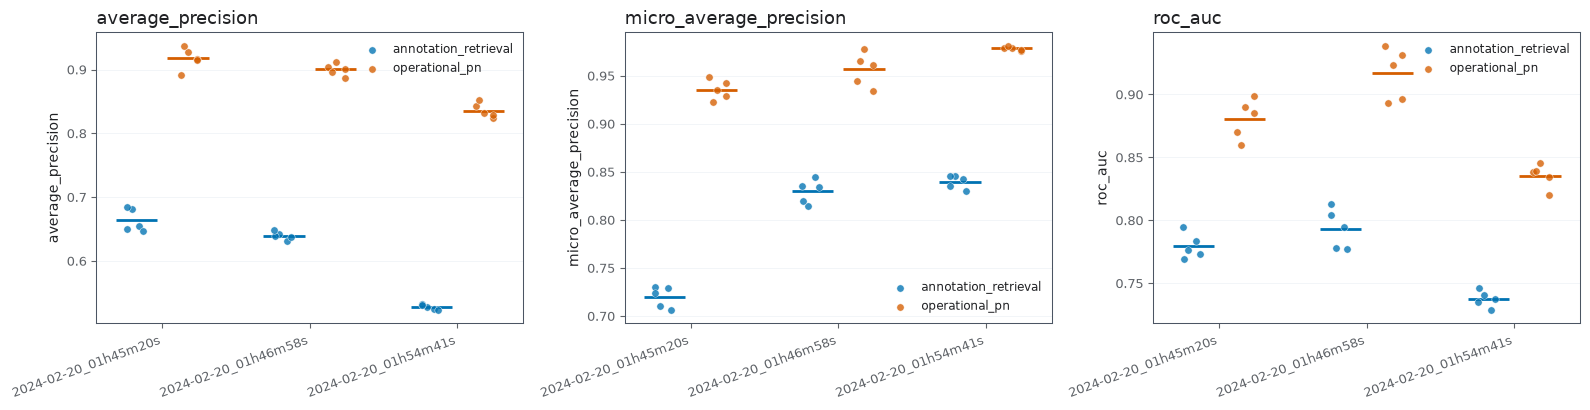

In [6]:
images = table('image_prediction')
images = images[images.scope == 'train_supported']
figure, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=theme.figure_dpi)
for ax, metric in zip(axes, ['average_precision', 'micro_average_precision', 'roc_auc']):
    figures.repetition_points(images[images.metric == metric], value='value', group='group', hue='population', order=DATASETS, hue_order=['annotation_retrieval', 'operational_pn'], colors={'annotation_retrieval': theme.model_palette[0], 'operational_pn': theme.model_palette[1]}, ylabel=metric, title=metric, ax=ax, theme=theme)
figure.tight_layout()
display(metric_table(images, ['population'], 'group', DATASETS))

### Remarks

- Per image: macro AP 0.53-0.66, micro AP 0.72-0.84, micro recall 0.21-0.34, Hamming 0.26-0.38; per-image values exceed the pooled ones for the same reason as on the narrow axis.

### Notes

## Per-class average precision

### Methodology

#### Theoretical

The distribution of per-class AP shows whether the macro mean reflects most classes or is carried by a few;
AP against training support shows how much a class needs to be learned.

#### Implementation

`per_class` rows of eligible classes, ranking population `annotation_retrieval`; repetition means for the scatter.

#### Figure descriptions

First figure: x = evaluation population, violin = per-class AP pooled over repetitions, diamonds = macro AP per
repetition. Second: x = training positives (log), y = repetition-mean AP (test + extension), colour = support
frequency bucket. Third: the same for every held-out image separately (one panel per image, AP of the classes
annotated in that image), to show how the dependence on training support differs between new images.

,classes,median_ap
group,,
2024-02-20_01h45m20s,9,0.7762
2024-02-20_01h46m58s,11,0.8455
2024-02-20_01h54m41s,13,0.5853


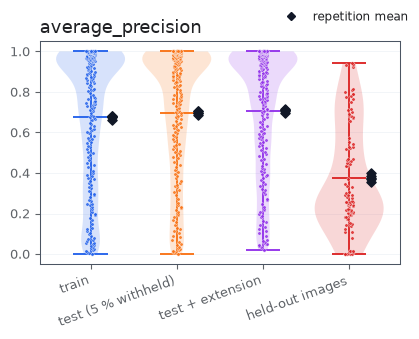

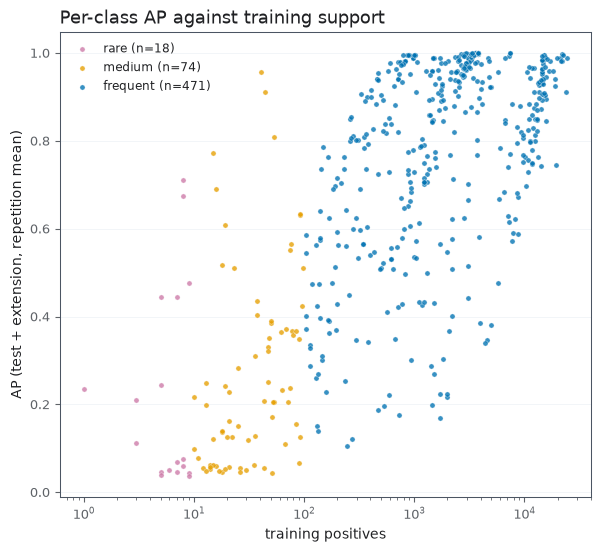

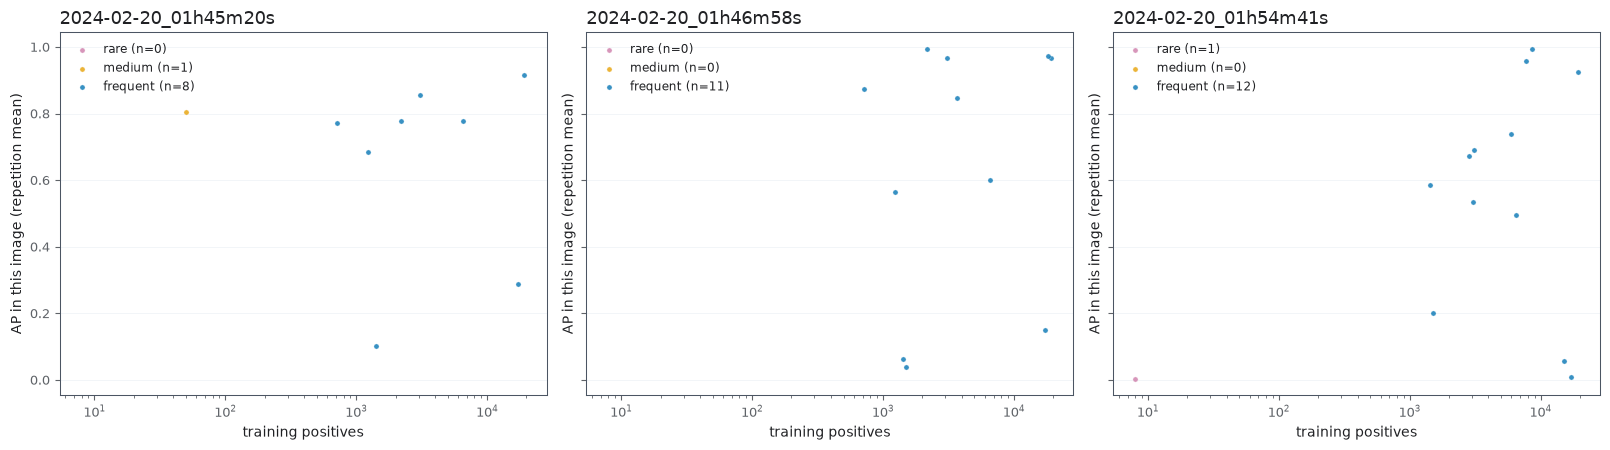

In [7]:
per_class = table('per_class')
image_classes = per_class[(per_class.group != 'all') & per_class.eligible.astype(bool) & (per_class.population == 'annotation_retrieval')]
per_class = per_class[per_class.group == 'all']
eligible = per_class[per_class.eligible.astype(bool) & (per_class.population == 'annotation_retrieval')].rename(columns={'population': 'ranking', 'evaluation': 'population'})
means = eligible.groupby(['repetition', 'population']).average_precision.mean().reset_index(name='mean').assign(metric='average_precision')
figures.population_distributions(eligible, means, ['average_precision'], EVALUATIONS, columns=1, theme=theme);
classes = eligible[eligible.population == 'test_combined'].groupby(['class_name', 'frequency'], as_index=False).agg(train_positives=('train_positives', 'first'), average_precision=('average_precision', 'mean'))
figures.paired_scatter(classes, x='train_positives', y='average_precision', hue='frequency', hue_order=['rare', 'medium', 'frequent'], xlabel='training positives', ylabel='AP (test + extension, repetition mean)', title='Per-class AP against training support', diagonal=False, colors={'rare': theme.model_palette[3], 'medium': theme.model_palette[4], 'frequent': theme.model_palette[0]}, theme=theme).axes[0].set_xscale('log')
per_image = image_classes.groupby(['group', 'class_name', 'frequency'], as_index=False).agg(train_positives=('train_positives', 'first'), average_precision=('average_precision', 'mean'))
figure, axes = plt.subplots(1, len(DATASETS), figsize=(5.4 * len(DATASETS), 4.6), dpi=theme.figure_dpi, sharex=True, sharey=True)
for ax, dataset in zip(axes, DATASETS):
    figures.paired_scatter(per_image[per_image.group == dataset], x='train_positives', y='average_precision', hue='frequency', hue_order=['rare', 'medium', 'frequent'], xlabel='training positives', ylabel='AP in this image (repetition mean)', title=dataset, diagonal=False, colors={'rare': theme.model_palette[3], 'medium': theme.model_palette[4], 'frequent': theme.model_palette[0]}, ax=ax, theme=theme)
    ax.set_xscale('log')
figure.tight_layout()
display(per_image.groupby('group').agg(classes=('class_name', 'size'), median_ap=('average_precision', 'median')))

### Remarks

- Per image 9 / 11 / 13 eligible classes with median AP 0.78 / 0.85 / 0.59; the dependence on training support is weak (Spearman 0.22-0.32).

### Notes

## Score distributions by evidence state

### Methodology

#### Theoretical

A useful head scores evidence positives above unlabelled entries and those above operational negatives.
Quantiles of $\hat Y$ per state show the separation and the calibration level.

#### Implementation

`score_diagnostics` holds quantiles of the positive probability per state, evaluation and repetition.

#### Figure descriptions

No figure; repetition-mean median and 90 % quantile of the probability per state and evaluation.

In [8]:
scores = table('score_diagnostics')
scores = scores[(scores.group == 'all') & (scores.quantity == 'positive_probability') & scores['quantile'].isin([0.5, 0.9])]
display(scores.pivot_table(index=['state', 'quantile'], columns='evaluation', values='value', aggfunc='mean')[[column for column in EVALUATIONS + ['test_extended'] if column in set(scores.evaluation)]])

,evaluation,train,test,test_combined,heldout_image,test_extended
state,quantile,,,,,
N,0.5,2.1891e-08,2.2031e-08,5.4952e-08,1.9779e-07,6.9759e-07
P,0.5,9.8042e-01,9.8025e-01,9.5451e-01,1.7777e-01,8.5453e-01
U,0.5,3.4256e-07,3.4504e-07,4.5261e-07,5.6856e-07,1.4043e-06


### Remarks

- Median probability of evidence positives 0.98 (test) vs 0.18 (held-out images).

### Notes

## Results / Summary

### LLM

- **Observed:** the complete metric set matches the narrow axis on test pixels and on held-out images (per-image macro AP 0.53-0.66, micro recall 0.21-0.34).
- **Interpretation:** the wide axis neither helps nor harms the head on common classes; the generalization gap to new images (low recall at 0.5) is shared by both axes.

### Person